In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("student dataset.csv")

print(df.head())

  College_ID   IQ  Prev_Sem_Result  CGPA  Academic_Performance  \
0    CLG0030  107             6.61  6.28                     8   
1    CLG0061   97             5.52  5.37                     8   
2    CLG0036  109             5.36  5.83                     9   
3    CLG0055  122             5.47  5.75                     6   
4    CLG0004   96             7.91  7.69                     7   

  Internship_Experience  Extra_Curricular_Score  Communication_Skills  \
0                    No                       8                     8   
1                    No                       7                     8   
2                    No                       3                     1   
3                   Yes                       1                     6   
4                    No                       8                    10   

   Projects_Completed Placement  
0                   4        No  
1                   0        No  
2                   1        No  
3                   1       

In [3]:
print("Shape:", df.shape)
print(df.info())
print(df.describe())

Shape: (10000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB
None
                 IQ  Prev_Sem_Result          CGPA  Academic_Performance  \
count  10000.000000     10000.000000  10000.000000          10000.000000   
mean      99.471

In [4]:
print(df.isnull().sum())

College_ID                0
IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64


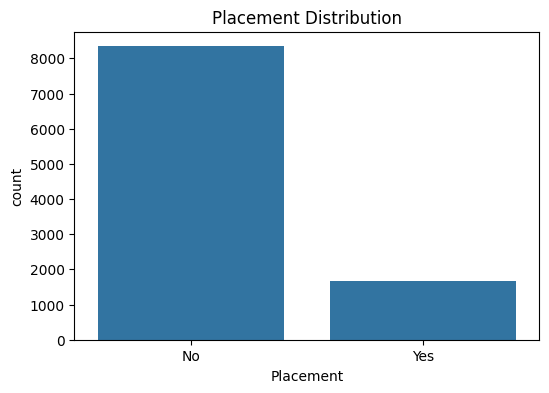

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='Placement', data=df)
plt.title("Placement Distribution")
plt.show()

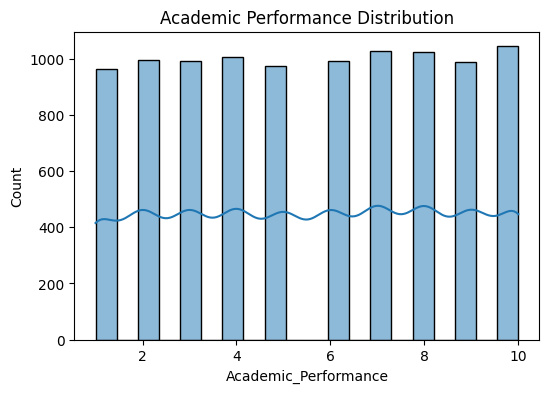

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df['Academic_Performance'], kde=True)
plt.title("Academic Performance Distribution")
plt.show()

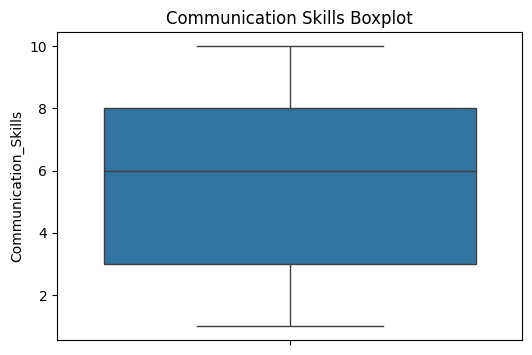

In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['Communication_Skills'])
plt.title("Communication Skills Boxplot")
plt.show()

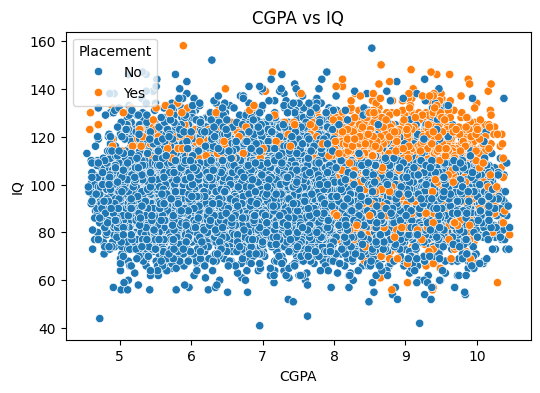

In [8]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='CGPA', y='IQ', hue='Placement', data=df)
plt.title("CGPA vs IQ")
plt.show()

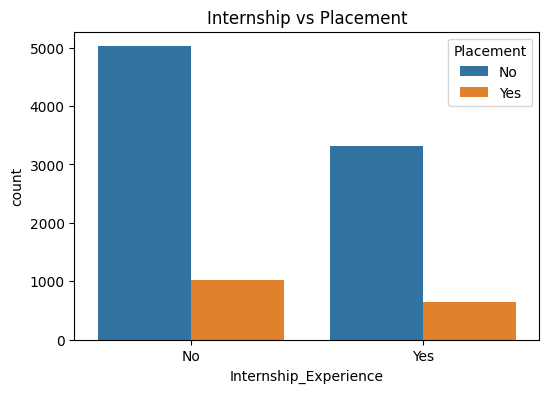

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Internship_Experience', hue='Placement', data=df)
plt.title("Internship vs Placement")
plt.show()

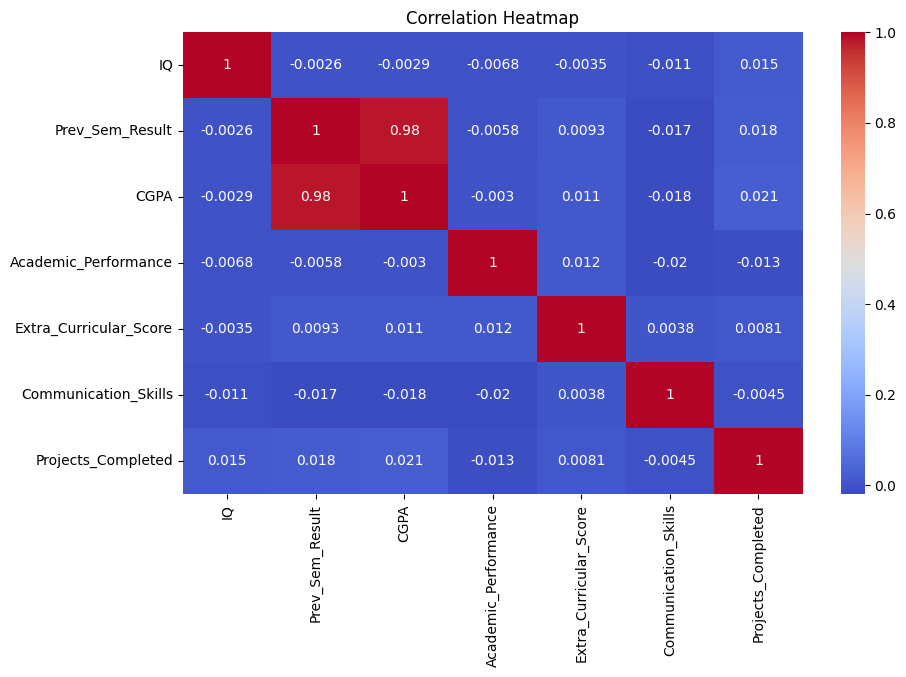

In [10]:
numeric = df.select_dtypes(include='number')

plt.figure(figsize=(10,6))
sns.heatmap(numeric.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

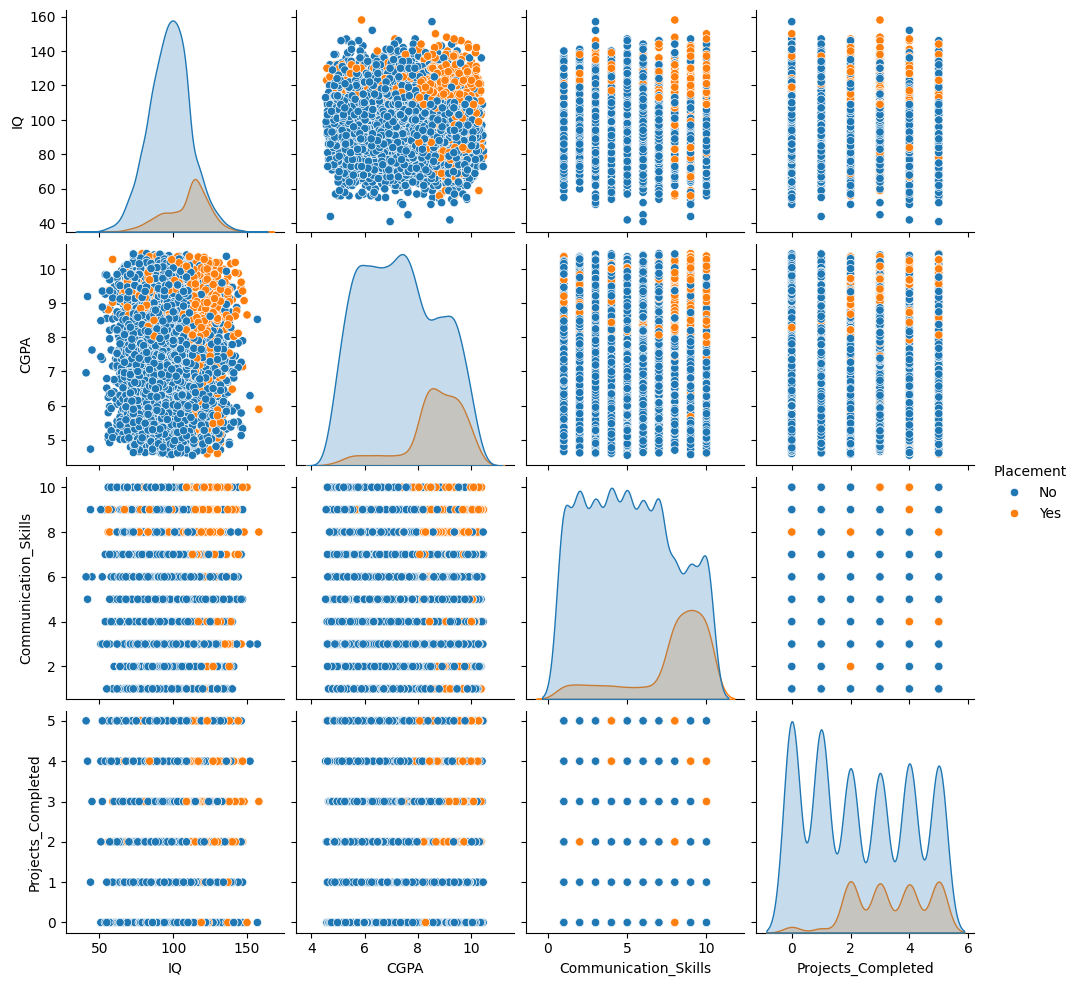

In [11]:
sns.pairplot(df[['IQ','CGPA','Communication_Skills','Projects_Completed','Placement']], hue='Placement')
plt.show()

In [12]:
le = LabelEncoder()

df['Internship_Experience'] = le.fit_transform(df['Internship_Experience'])
df['Placement'] = le.fit_transform(df['Placement'])

df.drop("College_ID", axis=1, inplace=True)

In [13]:
X = df.drop("Placement", axis=1)
y = df["Placement"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)  # limit depth to avoid overfitting
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [15]:
y_pred = model.predict(X_test)

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred)*100)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 100.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1674
           1       1.00      1.00      1.00       326

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



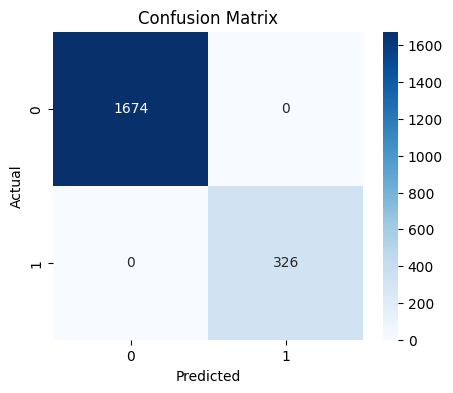

In [17]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

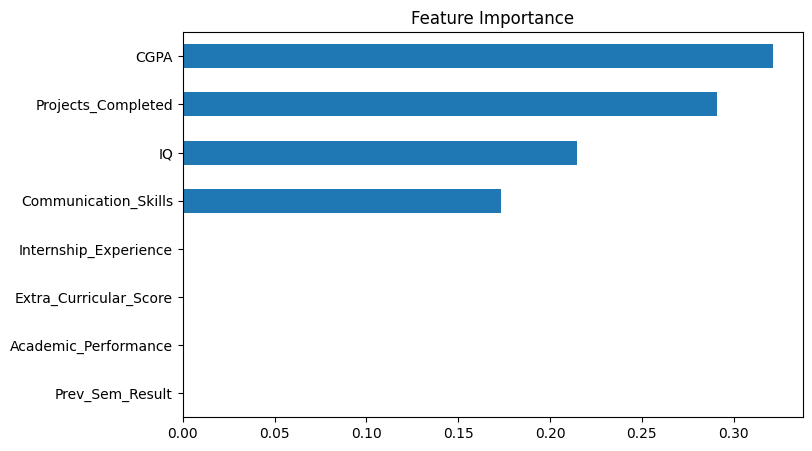

In [18]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance")
plt.show()

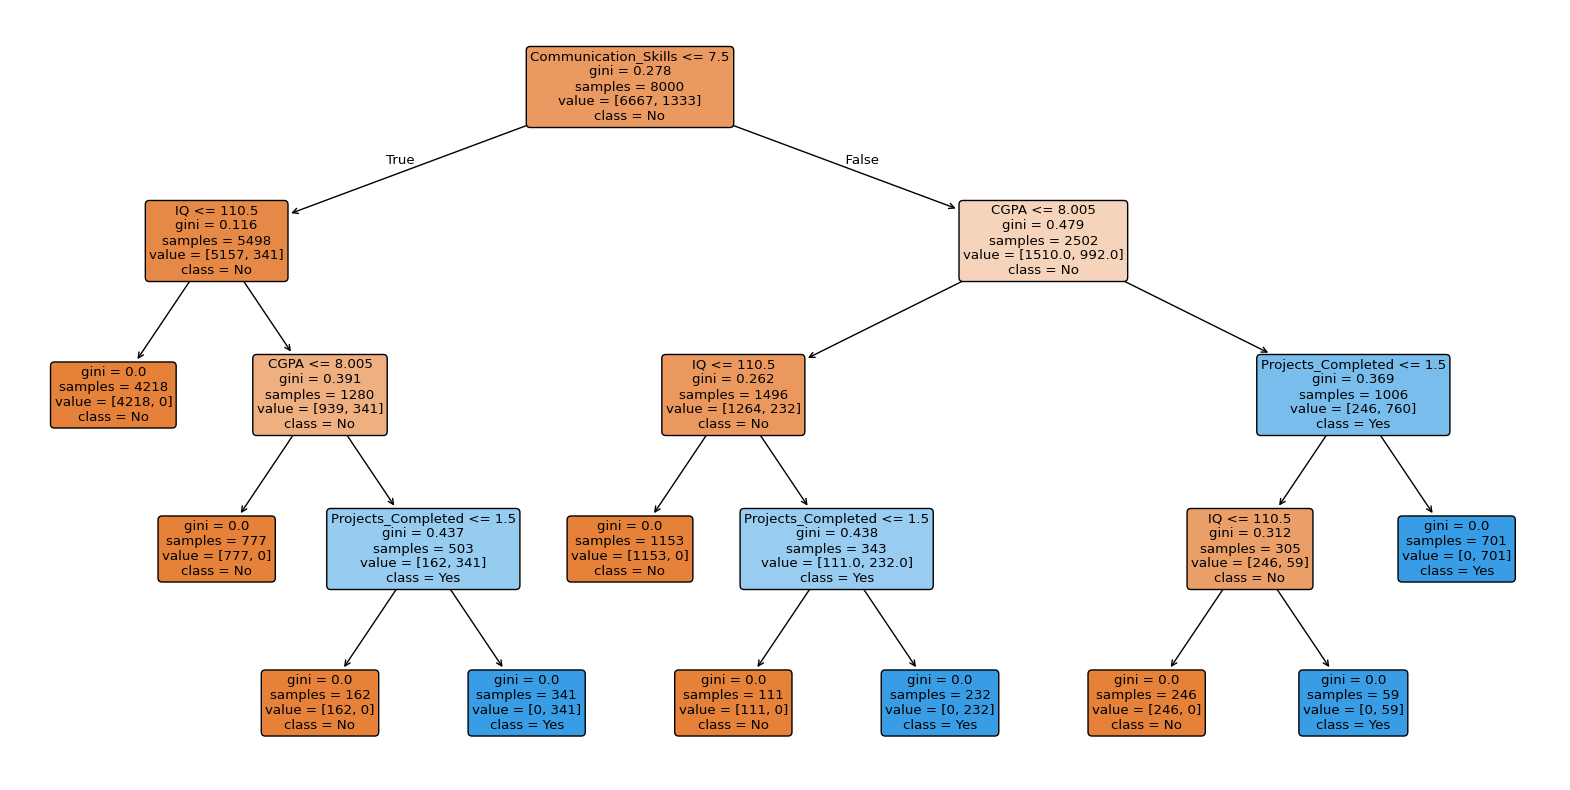

In [19]:
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=["No","Yes"],
          filled=True, rounded=True)
plt.show()